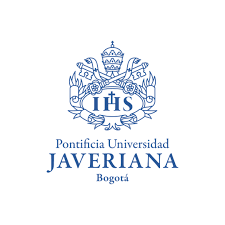
***Pontificia Universidad Javeriana***
# **Procesamiento de Alto Volumen de Datos**

### Taller: **Tratamiento de Datos y Machine Learning con PySpark**

Autor: Dana Katalina Diaz Diaz

Fecha de Inicio: 14/04/2026

Fecha actual:28/04/2026

## **Problemática**

Se tiene que el tratamiento del agua debe ser indispensable para garantizar la pureza y la calidad. Uno de los elementos significativos es aplicar los conceptos de los Procesamientos de Datos en Alto Volúmen para solucionar este tipo de problemas que afectan la salud publica. El presente ejemplo tiene como propósito tener en cuenta una metodogología para aplicar el PAVD para solucionar o diagnósticar la calidad del agua en la INDIA.

## **Objetivo**

Implementar modelos de predicción utilizando la biblioteca de aprendizaje automático MLlib PySpark, con el fin de explorar y aplicar técnicas de IA en entornos de procesamiento con alto volúmen de datos.


## **Metodología**

1.- Importación de los datos (datos en diferentes formatos)

2.- Preprocesamiento y limpieza de valores nulos, cambio de datos, EDA, medidas estadísticas.

3.- Entrenamiento de modelos: RL (MLlib), tensores (KERAS); la idea es predecir la calidad del agua en la INDIA.

4.- Evaluación de los modelos: medidas de rendimiento tales como: precisión (precision), exactitud (accuracy), recall, F1 Score,entre otras.

5.- Se tiene como referencia de la calidad de los parámetros del agua, la referencia: https://www.intechopen.com/chapters/69568

## **1.- Preparación del entorno**

### *1.1 Importación de bibliotecas*

In [ ]:
# Levantamiento de variables de entorno pip
import os                      #---> Acceso a las variables del sistema
import sys
sys.path.append('/usr/lib/python3/dist-packages/') #---> Ruta de paquetes del sistema


import pandas as pd             #---> Graficar objetos y dataFrame
import numpy as np              #---> Formato de Álgebra Matricial
import matplotlib.pyplot as plt #---> Formato de gráficas
import seaborn as sns           #---> Para estadísticas y graficar

from pylab import *             #---> Importa elementos al tiempo de numpy y matplotlib

# Inicialización de PySpark
import findspark
findspark.init()               #---> Inicializar el entorno Spark

import pyspark.sql.functions as F          # --->Funciones de Spark SQL
from pyspark import SparkConf, SparkContext # --->Configuración y contexto base de Spark
from pyspark.sql import SQLContext         # --->Interfaz SQL sobre el SparkContext
from pyspark.sql import SparkSession       # --->Punto de entrada principal a la API de Spark (recomendado)
from pyspark.sql.types import *            # --->Tipos de datos Spark

**Resultado:** Se importan todas las librerías necesarias para el proyecto: las de Python clásico (pandas, numpy, matplotlib, seaborn) para manejo y visualización de datos, y las de PySpark para poder trabajar con procesamiento distribuido de grandes volúmenes de datos.

### *1.2 Levantamiento de sesión SPARK*

In [ ]:
configura = SparkConf() #---> Se crea el objeto de configuración
configura.setAppName("Calidad_Agua_Diaz")

#Se construye la configuración Spark
sparkDiaz = SparkSession.builder.config(conf=configura).getOrCreate()
SQLContext(sparkContext=sparkDiaz.sparkContext, sparkSession=sparkDiaz)
sparkContextoS = sparkDiaz.sparkContext.getOrCreate()  #---> Se crea la sesión

#Información de la sesión activa
print("Sesion creada: ProcesamientoDatos04")
sparkDiaz

Sesion creada: ProcesamientoDatos04


**Resultado:** Se levanta la sesión de Spark "Calidad_Agua_Diaz", para poder ejecutar todo el procesamiento distribuido de datos.

## **2.- Carga de Datos desde el HADOOP HDFS**

In [ ]:

# Se carga el archivo waterquality.csv desde el HDFS en un DataFrame Spark
df00 = sparkDiaz.read.format("csv").option("header", "true").load("hdfs://10.195.34.34:9000/csv/waterquality.csv")
df00.show(5) # ---> Se listan las primeras 5 filas para revisar que se haya cargado


+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|         735|3.4|                  2|             3|            73|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|  6|  8|         270|3.1|                  2|            72|           182|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|         355|4.2|                  9|            59|           133|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|         371|5.6|               3.55|            90|           283|
|        2183|GODAVARI RIVER AT...|MAHARASHTRA|25.7|5.7|7.9|         294|3.2|               2.69|       

**Resultado**: Se cargan los datos de un CSV en un DataFrame de Spark y se verifica con la impresión de las primeras 5 columnas de estos

## **3.- Análisis y Preparación de Datos**

Se presentan datos (csv) con los diferentes parámetros de los rios de la India. Cada parámetro es el promedio de los valores medidos en un período de tiempo. Los datos han sido extraidos de la web oficial de la India (RiverIndia)

- Tipos de datos: coherencia de tipo de datos, transformación
- Columnas: conocimiento de las columnas, eliminación.
- Análisis de datos nulos o imposibles: concimiento.

### *3.1 Inspección de columnas*

In [ ]:
##Conocimiento de las columnas
df00.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'TOTAL_COLIFORM']

**¿Qué significa cada columna?**
- STATION CODE: Código de estación de medida
- LOCATIONS: ubicaciones de los rios
- STATE: Estado de la india
- TEMP: Temperatura del agua en °C
- DO: Oxigeno Disuelto (mg/L). Concentraciones altas de oxigeno representa mejor calidad del agua.
- pH: Logaritmo negativo de la concentración de hidrógeno. Número adimensional para indicar la acidez del agua.
- CONDUCTIVITY: Mide la habilidad de una solución conducir corriente. El agua pura NO es conductora de corriente.
- BOD: Bacterias y otros microorganismos que utilizan sustancias orgánicas como alimento: Demanda Bioquímica de Oxigeno. Mayor cantidad de material orgánico mayor BOD.
- NITRATE_N_NITRITE_N: Nitratos/Nitritos "nitrógeno". Altas concentraciones Nitrogeno en la superficie del agua puede estimular el rápido crecimiento de algas las cuales degradan la calidad del agua (mg/L).
- FECAL_COLIFORM: Promedio de bacterias coliformes: excresiones.
- TOTAL_COLIFORM']: Se eliminará pues no aporta al estudio de predicción de la calidad del agua.

### *3.2 Estadísticos descriptivos*

**Se presenta las estadísticas de los datos a continuación:**

In [ ]:
##Se revisa columna por columna las estadísticas
for valor in df00.columns:

  df00.describe([valor]).show()

+-------+-----------------+
|summary|     STATION CODE|
+-------+-----------------+
|  count|              534|
|   mean|2052.516853932584|
| stddev|755.2178560086894|
|    min|             1023|
|    max|               41|
+-------+-----------------+

+-------+-------------------+
|summary|          LOCATIONS|
+-------+-------------------+
|  count|                534|
|   mean|               NULL|
| stddev|               NULL|
|    min|          AHMEDABAD|
|    max|ZUARI AT PANCHAWADI|
+-------+-------------------+

+-------+--------------+
|summary|         STATE|
+-------+--------------+
|  count|           534|
|   mean|          NULL|
| stddev|          NULL|
|    min|ANDHRA PRADESH|
|    max|   WEST BENGAL|
+-------+--------------+

+-------+------------------+
|summary|              TEMP|
+-------+------------------+
|  count|               534|
|   mean|25.241398865784515|
| stddev|3.4480130875026624|
|    min|              10.5|
|    max|                NA|
+-------+---------

**Observaciones**: Todas las columnas tienen 534 registros, por lo que no hay filas faltantes, pero sí valores NA como texto (no nulos reales), lo que explica por qué el max de varias columnas aparece como "NA" en lugar de un número. Esto debe corregirse antes de entrenar el modelo.

### *3.3 Visualización con Boxplots para revisar el comporamiento general*

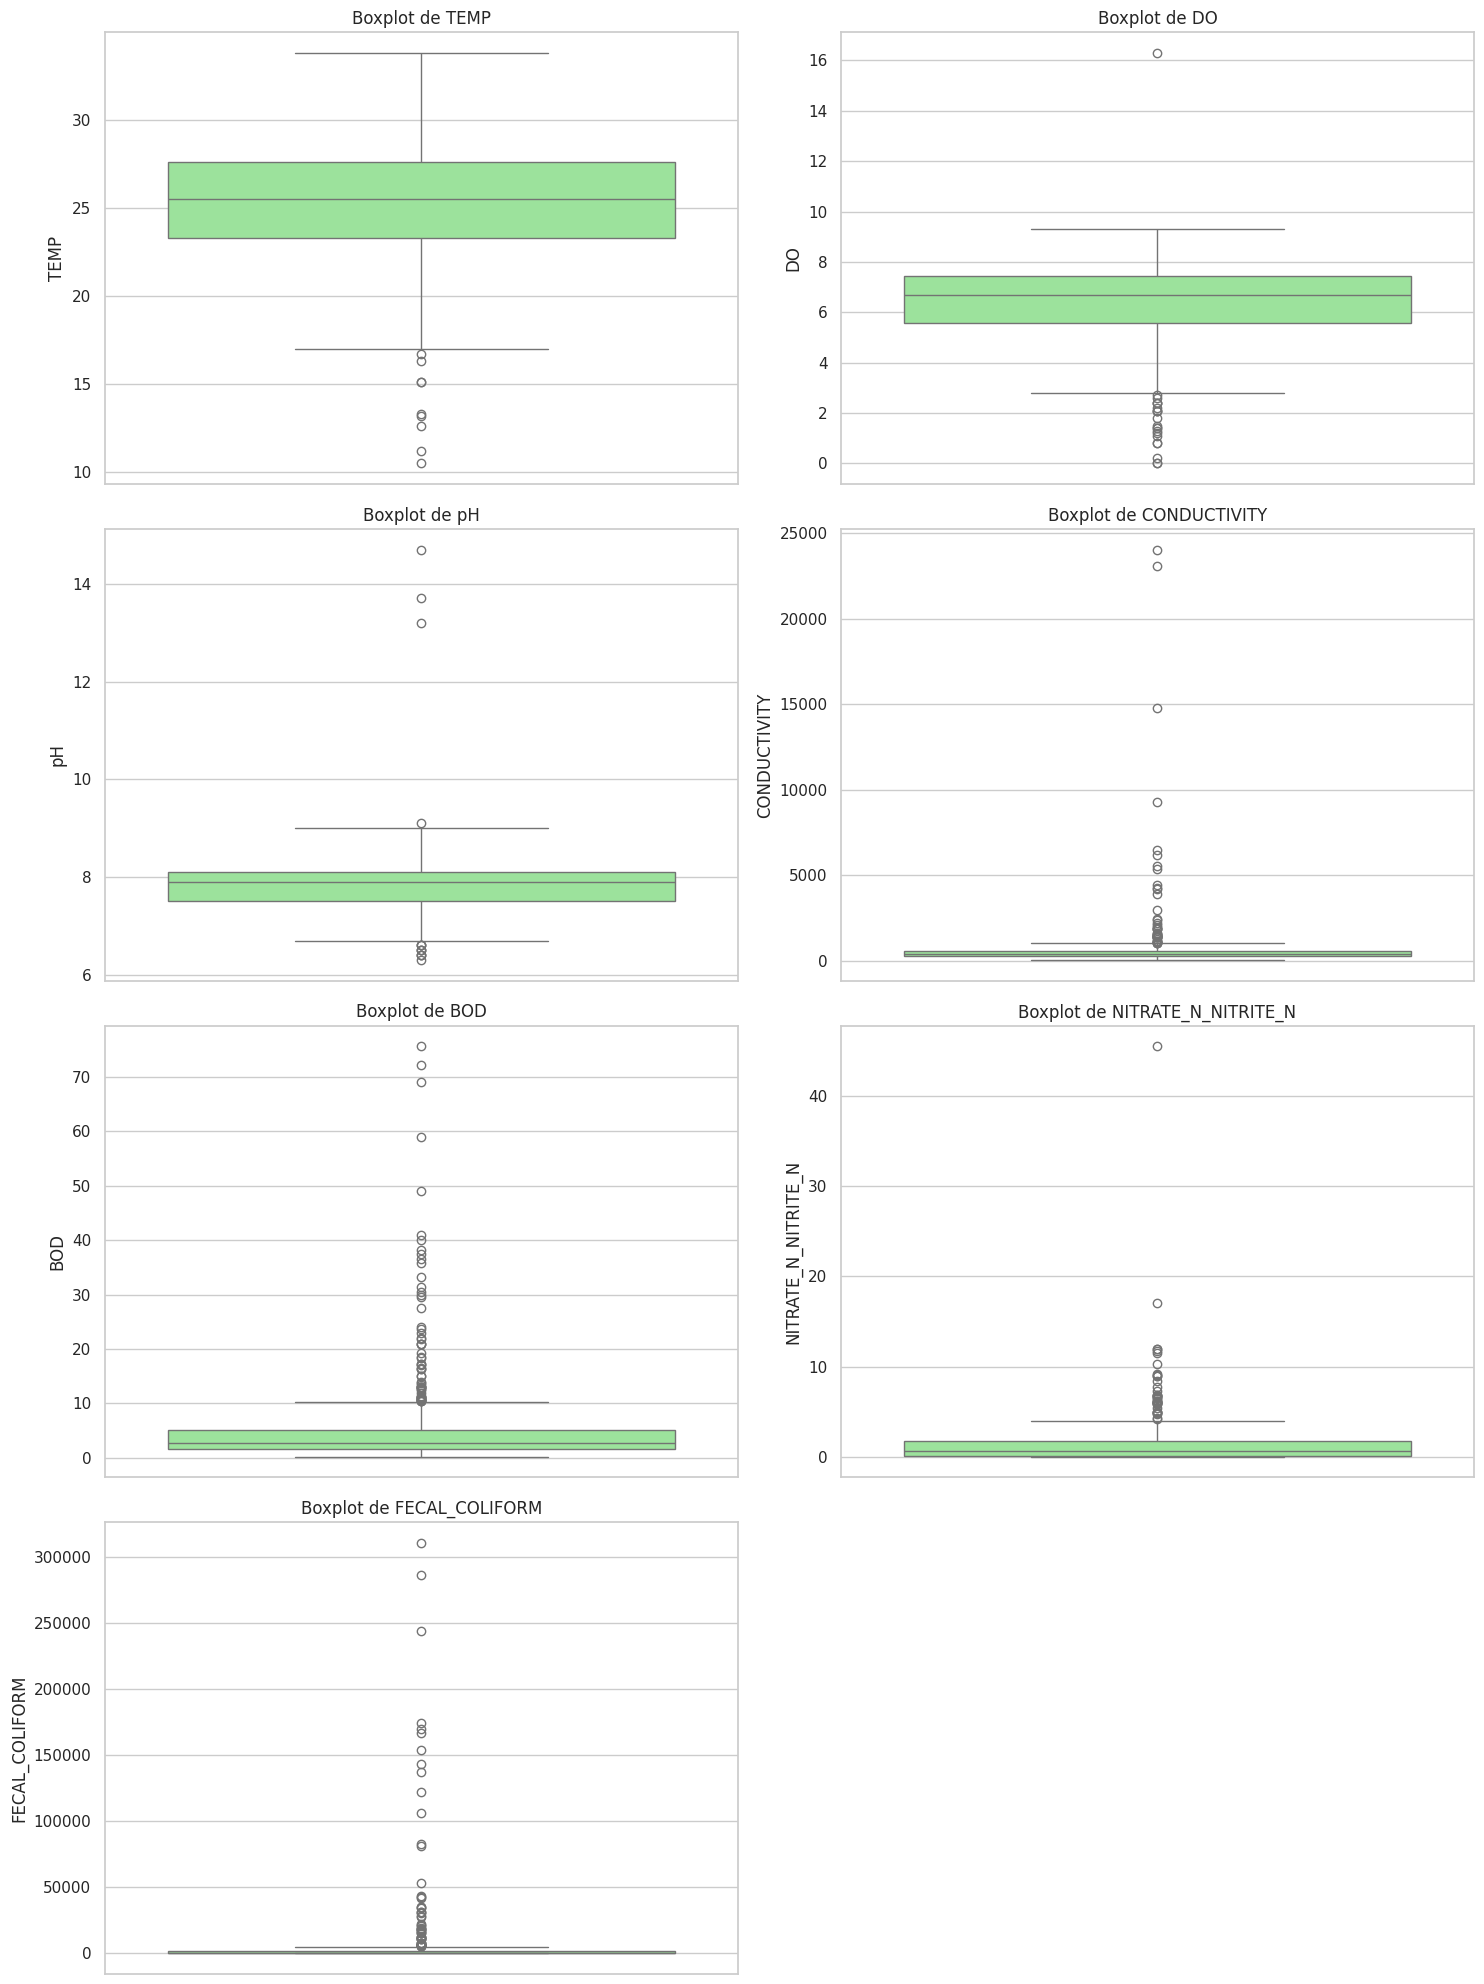

In [ ]:
#Se convierten las columnas numéricas a pandas para poder graficarlas con matplotlib
columnas = ["TEMP", "DO", "pH", "CONDUCTIVITY", "BOD", "NITRATE_N_NITRITE_N", "FECAL_COLIFORM"]

# Pasar de PySpark a pandas (solo columnas necesarias)
df_pandas = df00.select(columnas).toPandas()
df_pandas = df_pandas.apply(pd.to_numeric, errors='coerce')

# Configuración visual
sns.set(style="whitegrid")
plt.figure(figsize=(15,20))

# Boxplots por parámetro
for i, var in enumerate(columnas, 1):
    plt.subplot(4,2,i)
    sns.boxplot(y=df_pandas[var], color="lightgreen")
    plt.title(f"Boxplot de {var}")
    plt.ylabel(var)

plt.tight_layout()
plt.show()


**Observaciones y resultados:**
A partir del análisis de los estadísticos descriptivos y los diagramas de cajas y bigotes de las variables TEMP, DO, pH, CONDUCTIVITY, BOD, NITRATE_N_NITRITE_N y FECAL_COLIFORM, se evidencia la presencia de valores atípicos en todas ellas, lo que indica la existencia de observaciones que se alejan considerablemente del comportamiento general de los datos.

Asimismo, se observa que varias variables presentan distribuciones asimétricas, especialmente CONDUCTIVITY, BOD, NITRATE_N_NITRITE_N y FECAL_COLIFORM, donde la mayoría de los valores se concentran en rangos bajos mientras que algunos registros alcanzan magnitudes significativamente altas, generando un sesgo positivo. En contraste, variables como TEMP, DO y pH muestran una distribución relativamente más estable, aunque no están exentas de valores extremos.

Debido a esta asimetría y a la alta variabilidad (CV > 30%), la media se ve influenciada por los valores atípicos y no representa adecuadamente la tendencia central de los datos, por lo que se justifica el uso de la mediana como medida más robusta para la imputación de valores faltantes en algunas estas variables

### *3.4 Tratamiento de datos*

In [ ]:
#Se empieza revisando los tipos de datos
df00.printSchema()

root
 |-- STATION CODE: string (nullable = true)
 |-- LOCATIONS: string (nullable = true)
 |-- STATE: string (nullable = true)
 |-- TEMP: string (nullable = true)
 |-- DO: string (nullable = true)
 |-- pH: string (nullable = true)
 |-- CONDUCTIVITY: string (nullable = true)
 |-- BOD: string (nullable = true)
 |-- NITRATE_N_NITRITE_N: string (nullable = true)
 |-- FECAL_COLIFORM: string (nullable = true)
 |-- TOTAL_COLIFORM: string (nullable = true)



**Decisiones**:
- Se debe cambiar los tipos Float a FloatType con el objetivo de asegurar la correcta interpretación numérica dentro del DataFrame de PySpark. Esta transformación es necesaria debido a que Spark utiliza su propio sistema de tipos de datos.
- Además se elimina la columna total_coliform ya que como se indicó, es irrelevante para este enfoque

In [ ]:

df00.dtypes
##Se procede a cambiar los tipos de datos
df00 = df00.withColumn('TEMP', df00['TEMP'].cast(FloatType()))
df00 = df00.withColumn('pH', df00['pH'].cast(FloatType()))
df00 = df00.withColumn('DO', df00['DO'].cast(FloatType()))
df00 = df00.withColumn('CONDUCTIVITY', df00['CONDUCTIVITY'].cast(FloatType()))
df00 = df00.withColumn('NITRATE_N_NITRITE_N', df00['NITRATE_N_NITRITE_N'].cast(FloatType()))
df00 = df00.withColumn('FECAL_COLIFORM', df00['FECAL_COLIFORM'].cast(FloatType()))
df00 = df00.withColumn('BOD', df00['BOD'].cast(FloatType()))
df00.dtypes


##Se elimina la columna TOTAL_COLIFORM
df001 = df00.drop('TOTAL_COLIFORM')
df001.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM']

### *3.5 Revisión de datos nulos tras el casteo*


In [ ]:
#Cantidad de Valores Nulos o Imposibles
df001.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df001.columns]).show()

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+
|           0|        0|    0|   5|  2|  0|          30|  6|                  2|            82|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+



**Observaciones**
* Se observa que las columnas "CONDUCTIVITY", "DO", "STATE", "NITRATE_N_NITRITE_N", pH Y "FECAL_COLIFORM" presentan nulos, dependiendo de cada caso se tomarán acciones.


### *3.6 Cálculo de coeficiente de variación para decidir imputación*

In [ ]:
#Cálculo del Coeficiente de Variación (CV) por columna
# CV = (Desviación Estándar / Media) × 100
# Si CV < 30%  → se imputa con la MEDIA
# Si CV >= 30% → se imputa con la MEDIANA

from pyspark.sql.functions import mean, stddev

columnas_cv = ["TEMP", "DO", "pH", "CONDUCTIVITY", "BOD", "NITRATE_N_NITRITE_N", "FECAL_COLIFORM"]

# Encabezado de la tabla de resultados
print(f"{'Parámetro':<25} {'Media':>10} {'Std':>12} {'CV (%)':>10} {'Decisión':>10}")
print("-" * 72)

# Se itera sobre cada columna para calcular sus estadísticos
for col in columnas_cv:

    # Se calculan la media y desviación estándar desde Spark en una sola acción
    stats = df00.select(
        mean(col).alias("media"),
        stddev(col).alias("std")
    ).collect()[0]

    media = stats["media"]
    std   = stats["std"]

    # Se calcula el CV como porcentaje de dispersión relativa
    cv = (std / media) * 100

    # Si el CV es menor al 30% los datos son poco dispersos y la media es representativa
    # Si el CV supera el 30% los datos están sesgados y se debe usar la mediana
    decision = "Media" if cv < 30 else "Mediana"

    # Se imprime la fila de resultados para la columna actual
    print(f"{col:<25} {media:>10.2f} {std:>12.2f} {cv:>10.1f}%   {decision:>10}")

Parámetro                      Media          Std     CV (%)   Decisión
------------------------------------------------------------------------
TEMP                           25.24         3.45       13.7%        Media
DO                              6.39         1.62       25.4%        Media
pH                              7.80         0.65        8.3%        Media
CONDUCTIVITY                  684.98      1769.33      258.3%      Mediana
BOD                             5.34         8.50      159.2%      Mediana
NITRATE_N_NITRITE_N             1.38         2.80      203.4%      Mediana
FECAL_COLIFORM               7384.17     30714.06      415.9%      Mediana


### **Decisiones**:
- Para determinar como imputar la media se revisará el Coeficiente de Variación (CV = Desviación Estándar / Media × 100), si su CV es menor al 30%, la media es suficientemente representativa. Para TEMP (CV=13.7%), pH (CV=8.3%) y DO (CV=25.4%) el CV es menor al 30%, lo que indica poca dispersión y hace que la media sea un buen sustituto.
- Para NITRATE (CV=203%), BOD (CV=159%), CONDUCTIVITY (CV=258%) y FECAL_COLIFORM (CV=416%) el CV supera ampliamente el 30%, lo que indica que los datos están muy sesgados por valores extremos y la media no es representativa, por lo tanto se usará la mediana.

### *3.7 Imputación de datos nulos*

In [ ]:
#Se importan las funciones necesarias para el cálculo de la media y mediana
from pyspark.sql.functions import mean, percentile_approx

# Imputación con MEDIA (CV < 30%)

# Se calcula la media de TEMP, pH y DO
media_TEMP = df001.select(mean("TEMP")).collect()[0][0]
media_pH = df001.select(mean("pH")).collect()[0][0]
media_DO = df001.select(mean("DO")).collect()[0][0]

# Se reemplazan los nulos por la media calculada
df001 = df001.fillna({"TEMP": media_TEMP, "pH": media_pH, "DO": media_DO})

# Imputación con MEDIANA (CV >= 30%)
# Se calcula la mediana de NITRATE, BOD, CONDUCTIVITY y FECAL_COLIFORM
mediana_NITRATE = df001.select(percentile_approx("NITRATE_N_NITRITE_N", 0.5)).collect()[0][0]
mediana_BOD = df001.select(percentile_approx("BOD", 0.5)).collect()[0][0]
mediana_CONDUCTIVITY = df001.select(percentile_approx("CONDUCTIVITY", 0.5)).collect()[0][0]
mediana_FECAL = df001.select(percentile_approx("FECAL_COLIFORM", 0.5)).collect()[0][0]

# Se reemplazan los nulos por la mediana calculada
df001 = df001.fillna({
    "NITRATE_N_NITRITE_N": mediana_NITRATE,
    "BOD": mediana_BOD,
    "CONDUCTIVITY": mediana_CONDUCTIVITY,
    "FECAL_COLIFORM": mediana_FECAL
})

In [ ]:
#Volvemos a revisar cantidad de Valores Nulos o Imposibles
df001.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df001.columns]).show()

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+
|           0|        0|    0|   0|  0|  0|           0|  0|                  0|             0|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+



**Resultado**: Con el casteo se evidencia que no quedan datos nulos

### *3.8 Filtrado final y creación de vista SQL*

In [ ]:
#Se crea una vista para ser usada en las visualizaciones
df001.createOrReplaceTempView("df001_sql")
df01 = sparkDiaz.sql('''Select * from df001_sql where TEMP is not null and

             DO is not null and

             pH is not null and

             CONDUCTIVITY is not null and

             BOD is not null and

             NITRATE_N_NITRITE_N is not null and

             FECAL_COLIFORM is not null''')

### **Resumen:**
Se inicia con la inspección de las columnas del dataset y la descripción de cada parámetro fisicoquímico. Luego se calculan los estadísticos descriptivos columna por columna para identificar el comportamiento general de los datos.
A partir de ese análisis se detecta que los valores NA fueron cargados como texto y no como nulos reales, lo que se evidencia en el max de varias columnas numéricas. Tras realizar el casteo a FloatType, estos NA se convierten en nulos reales de Spark, momento en el que se hace una visualización formal de los valores nulos por columna.
Para decidir cómo imputar cada columna se calcula el Coeficiente de Variación (CV), concluyendo que TEMP, pH y DO se imputan con la media (CV < 30%) y CONDUCTIVITY, BOD, NITRATE_N_NITRITE_N y FECAL_COLIFORM se imputan con la mediana (CV ≥ 30%). Finalmente, se eliminó la columna TOTAL_COLIFORM por ser irrelevante para el modelo, y se confirma mediante los boxplots que las variables con mayor dispersión presentan outliers extremos, lo que valida las decisiones de imputación tomadas.

## **4.-Visualización de datos**

## *Creación de Tablas para Visualizar los Datos*

- Se hace uso de la función LAMBDA para hacer el tratamiento/limpieza de los datos

- df01.createOrReplaceTempView("df01_sql")

### Se crea una consulta por cada parámetro DO
- do_parametro = sparkS.sql("Select DO from df01_sql")
## Se hace una consulta para crear el vector de la tabla por cada parámetro
- do_parametro = do_parametro.rdd.map(lambda fila: fila.DO).collect()

- pH
- CONDUCTIVITY
- BOD
- NITRATE_N_NITRITE_N
- FECAL_COLIFORM

## *4.1 Creación de Tablas para Visualizar los Datos*

In [ ]:
#Se hace uso de la función LAMBDA para hacer el tratamiento/limpieza de los datos

df01.createOrReplaceTempView("df01_sql")

###Se crea una consulta por cada parámetro
do_parametro = sparkDiaz.sql("Select DO from df01_sql")
ph_parametro = sparkDiaz.sql("Select pH from df01_sql")
COND_parametro = sparkDiaz.sql("Select CONDUCTIVITY from df01_sql")
BOD_parametro = sparkDiaz.sql("Select BOD from df01_sql")
NN_parametro = sparkDiaz.sql("Select NITRATE_N_NITRITE_N from df01_sql")
FC_parametro = sparkDiaz.sql("Select FECAL_COLIFORM from df01_sql")
##Se hace una consulta para crear el vector de la tabla por cada parámetro
ph_parametro = ph_parametro.rdd.map(lambda fila: fila.pH).collect()
COND_parametro = COND_parametro.rdd.map(lambda fila: fila.CONDUCTIVITY).collect()
BOD_parametro = BOD_parametro.rdd.map(lambda fila: fila.BOD).collect()
NN_parametro = NN_parametro.rdd.map(lambda fila: fila.NITRATE_N_NITRITE_N).collect()
FC_parametro = FC_parametro.rdd.map(lambda fila: fila.FECAL_COLIFORM).collect()
do_parametro = do_parametro.rdd.map(lambda fila: fila.DO).collect()



**Resultado final**: Cada variable (do_parametro, ph_parametro, etc.) queda como una lista de Python con todos los valores de su respectiva columna, lo que permite usarlos directamente con matplotlib para graficar, ya que matplotlib no trabaja con DataFrames de Spark sino con estructuras de Python o numpy.

## *4.2 Grafica Los parámetros para conocer sus características: DO y PH*

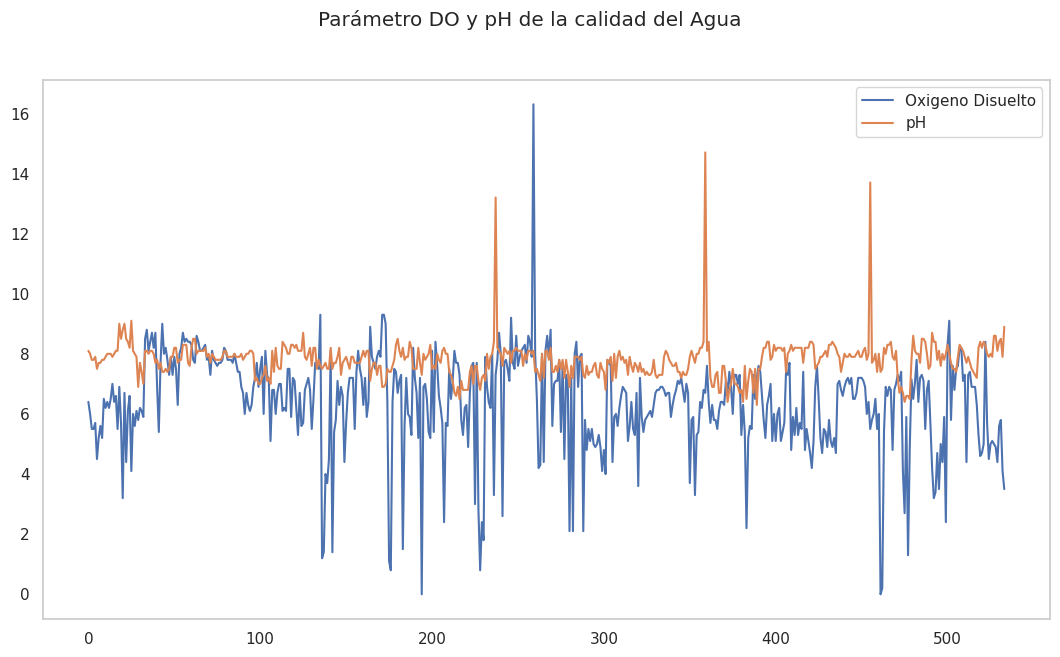

In [ ]:
tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
ax1.plot(range(0,tam), do_parametro, label='Oxigeno Disuelto')
ax1.plot(range(0,tam), ph_parametro, label='pH')
fig.suptitle('Parámetro DO y pH de la calidad del Agua')
legend=ax1.legend()
plt.grid()
plt.show()

**Análisis**: El gráfico muestra el comportamiento del oxígeno disuelto (DO) y el pH en las tomas.
Se observa que el pH se mantiene relativamente estable, con valores cercanos a la neutralidad (7–8), aunque presenta algunos picos aislados que podrían considerarse valores atípicos.
En contraste, el DO presenta una alta variabilidad, con fluctuaciones constantes y caídas pronunciadas, lo que sugiere cambios en las condiciones del agua (actividad biológica, temperatura o materia orgánica).
No se aprecia una relación directa entre ambas variables, ya que el pH permanece estable mientras el DO varía considerablemente.
En conjunto, el DO parece ser un indicador más sensible a cambios en la calidad del agua

 ### *4.3 Grafica Los parámetros para conocer sus características: BOD y Nitrogrenos*

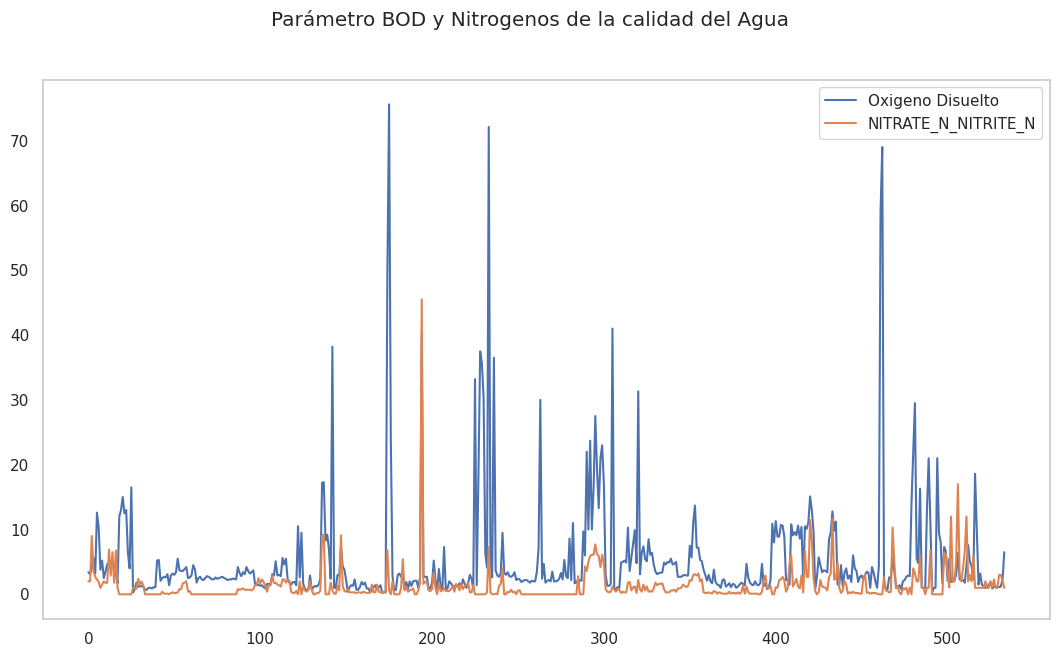

In [ ]:


tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
ax1.plot(range(0,tam), BOD_parametro, label='Oxigeno Disuelto')
ax1.plot(range(0,tam), NN_parametro, label='NITRATE_N_NITRITE_N')
fig.suptitle('Parámetro BOD y Nitrogenos de la calidad del Agua')
legend=ax1.legend()
plt.grid()
plt.show()

**Análisis**: El gráfico muestra el comportamiento conjunto de la DBO (BOD) y los compuestos de nitrógeno (NITRATE_N_NITRITE_N), evidenciando una alta variabilidad en ambas variables. La mayoría de los valores se concentran en niveles bajos; sin embargo, se observan picos pronunciados que indican eventos puntuales de contaminación o incrementos significativos de materia orgánica y nutrientes. La DBO presenta fluctuaciones más intensas y frecuentes, lo que sugiere cambios en la carga orgánica del agua, mientras que los nitratos y nitritos también muestran incrementos aislados que podrían estar asociados a descargas específicas o procesos de escorrentía. No se aprecia una relación constante entre ambas variables, aunque en algunos tramos los picos coinciden, lo que podría indicar una posible asociación en eventos de contaminación. Este comportamiento es consistente con estudios de calidad de agua que señalan que aumentos en nutrientes y materia orgánica suelen presentarse de forma episódica (APHA, 2017).

### *4.4 Grafica Los parámetros para conocer sus características: FC y Conductividad*

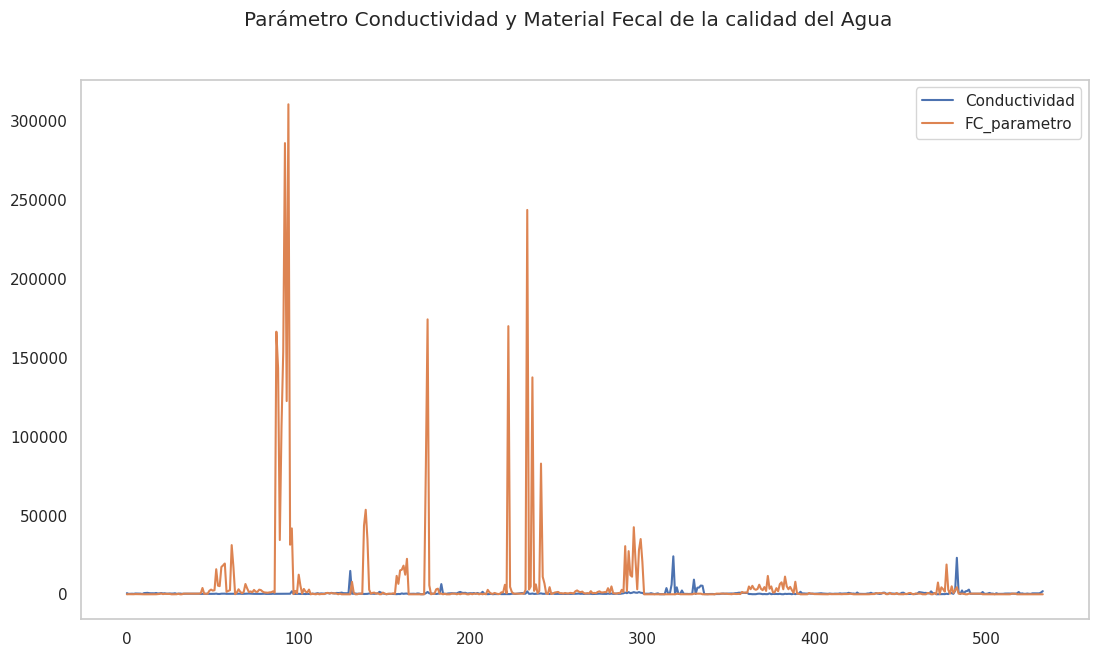

In [ ]:


tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
ax1.plot(range(0,tam), COND_parametro, label='Conductividad')
ax1.plot(range(0,tam), FC_parametro, label='FC_parametro')
fig.suptitle('Parámetro Conductividad y Material Fecal de la calidad del Agua')
legend=ax1.legend()
plt.xlabel("")
plt.grid()
plt.show()

**Análisis:** El gráfico muestra el comportamiento de la conductividad y el material fecal (FECAL_COLIFORM), evidenciando una alta variabilidad en ambas variables. Se observa que la mayoría de los valores se concentran en niveles bajos; sin embargo, existen picos extremadamente altos, especialmente en el material fecal, lo que indica eventos puntuales de contaminación significativa. La conductividad, aunque presenta menor magnitud en comparación, también muestra incrementos aislados que podrían estar asociados a cambios en la concentración de sales disueltas o descargas específicas. Debido a la gran diferencia de escala y la presencia de valores extremos, se realizará un análisis adicional de la conductividad mediante un gráfico independiente, con el fin de evaluar con mayor claridad su comportamiento.

### *4.5 Grafica Los parámetros para conocer sus características: Conductividad*

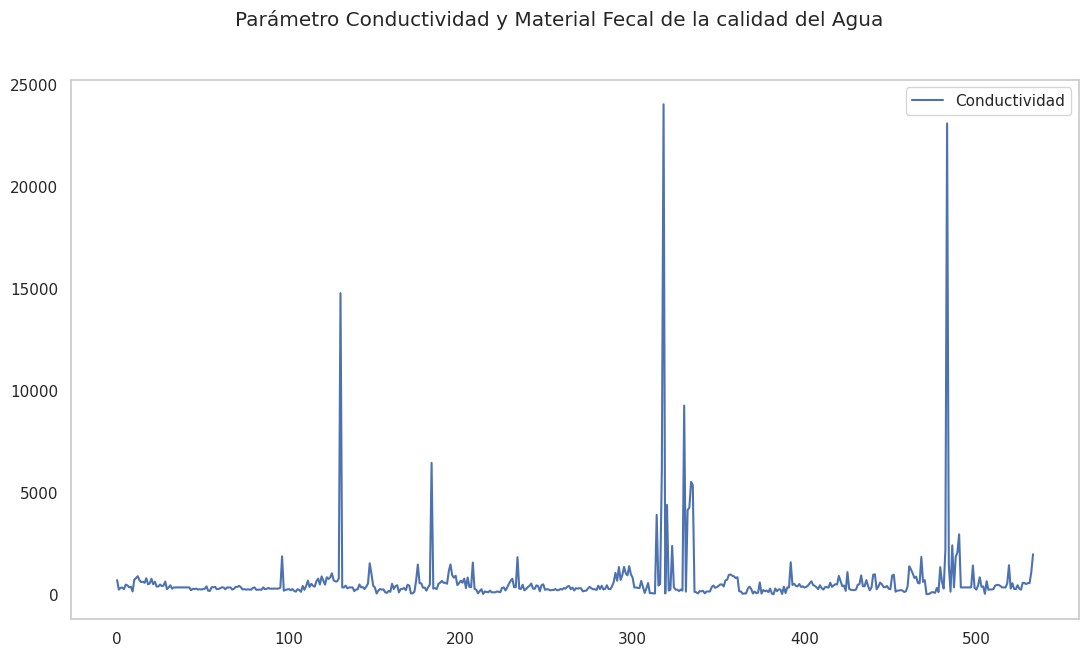

In [ ]:


tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
ax1.plot(range(0,tam), COND_parametro, label='Conductividad')
fig.suptitle('Parámetro Conductividad y Material Fecal de la calidad del Agua')
legend=ax1.legend()
plt.xlabel("")
plt.grid()
plt.show()

**Análisis:** El gráfico de conductividad permite observar con mayor claridad su comportamiento, evidenciando que la mayoría de los valores se concentran en rangos bajos a moderados, mientras que existen picos muy elevados que representan valores atípicos significativos. La distribución es claramente asimétrica, con sesgo positivo, lo que confirma una alta variabilidad en la variable.

## *4.6 Gráfica para revisar la relación entre los parámetros*
Con el fin de revisar la correlación entre las variables se va a realizar una matriz

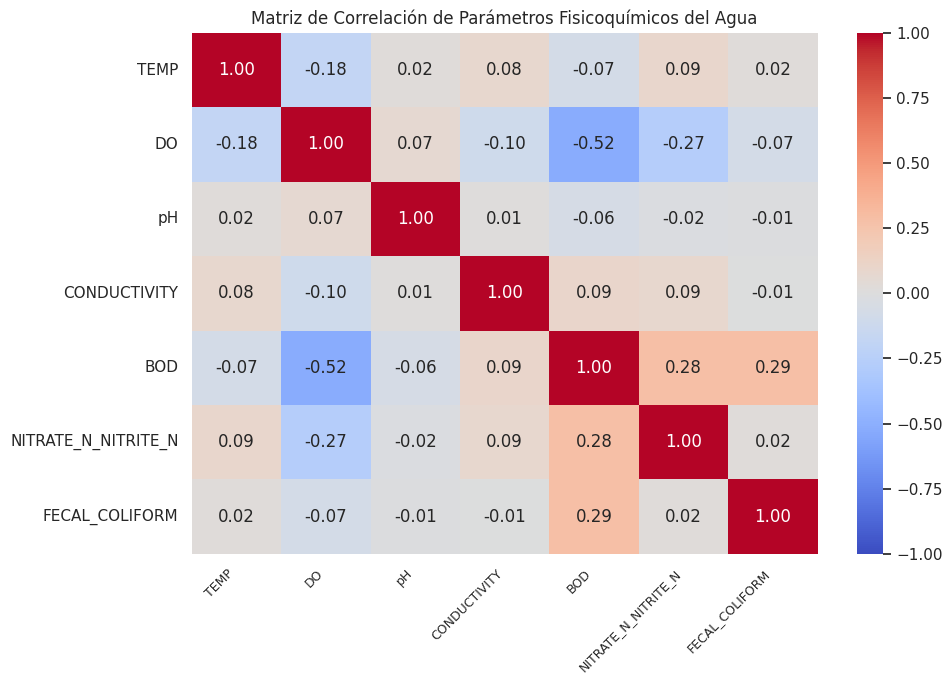

In [ ]:
# Se importa la librería para calcular la correlación
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler

# Se ensamblan las columnas numéricas en un solo vector
# que es el formato que requiere Spark para calcular correlación
columnas_corr = ["TEMP", "DO", "pH", "CONDUCTIVITY", "BOD", "NITRATE_N_NITRITE_N", "FECAL_COLIFORM"]

assembler = VectorAssembler(inputCols=columnas_corr, outputCol="features")
df_vector = assembler.transform(df001).select("features")

# Se calcula la matriz de correlación de Pearson
matriz_corr = Correlation.corr(df_vector, "features").collect()[0][0]

# Se convierte a numpy para poder graficarla con seaborn
import numpy as np
matriz_np = np.array(matriz_corr.toArray())

# Visualización de la matriz

plt.figure(figsize=(10, 7))
sns.heatmap(
    matriz_np,
    annot=True,           # Muestra los valores numéricos en cada celda
    fmt=".2f",            # Formato de 2 decimales
    cmap="coolwarm",      # Rojo = correlación positiva, Azul = negativa
    xticklabels=columnas_corr,
    yticklabels=columnas_corr,
    vmin=-1, vmax=1       # Escala fija entre -1 y 1
)
plt.title("Matriz de Correlación de Parámetros Fisicoquímicos del Agua")
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

**Análisis**: La matriz de correlación muestra que, en general, las relaciones entre las variables fisicoquímicas del agua son débiles, con coeficientes cercanos a cero en la mayoría de los casos. Sin embargo, se destaca una correlación negativa moderada entre el oxígeno disuelto (DO) y la DBO (BOD) (-0.52), lo cual es consistente con el comportamiento esperado, ya que un aumento en la demanda biológica de oxígeno implica un mayor consumo de oxígeno disuelto en el agua. Asimismo, se observan correlaciones positivas débiles entre BOD y NITRATE_N_NITRITE_N (0.28) y entre BOD y FECAL_COLIFORM (0.29), lo que podría indicar cierta relación entre la materia orgánica, los nutrientes y la contaminación microbiológica. El resto de las variables, como pH, temperatura y conductividad, presentan correlaciones muy bajas, lo que sugiere que no existe una relación lineal significativa entre ellas. En conjunto, estos resultados indican que la mayoría de los parámetros analizados varían de manera relativamente independiente, con algunas asociaciones puntuales que son coherentes con procesos de contaminación orgánica en el agua. (APHA, 2017).

## **5.-Cálculo del índice de calidad del agua**

### Se crea la columna para los rangos del parámetro (Según https://www.intechopen.com/chapters/69568)

### *5.1 Función definida por el usuario para definir el rango de calidad de agua según el pH*

In [ ]:

df02 = df01.withColumn("qrPH", F.when((df01.pH>=7) & (df01.pH<=8.5),100).  #--> Rango óptimo de pH
       when(((df01.pH>=6.8) & (df01.pH<6.9)) | ((df01.pH>8.5) & (df01.pH<8.6)), 80).  #--> Rango ligeramente fuera del óptimo
       when(((df01.pH>=6.7) & (df01.pH<6.8)) | ((df01.pH>=8.6) & (df01.pH<8.8)), 60).  #--> Rango moderadamente fuera del óptimo
       when(((df01.pH>=6.5) & (df01.pH<6.7)) | ((df01.pH>=8.8) & (df01.pH<9.0)), 40).  #--> Rango crítico
       otherwise(0))  #--> Valores fuera de los rangos aceptables

### *5.2 Función definida por el usuario para definir el rango de la calidad del agua según DO*

In [ ]:

df02 = df02.withColumn("qrDO", F.when((df01.DO>=6.0), 100). #--> Nivel óptimo de oxígeno disuelto
                    when((df01.DO>=5.1) & (df01.DO<6.0), 80). #--> Nivel ligeramente por debajo del óptimo
                    when((df01.DO>=4.1) & (df01.DO<5.0), 60). #--> Nivel moderadamente bajo
                    when((df01.DO>=3.0) & (df01.DO<=4.0), 40). #--> Nivel crítico de oxígeno disuelto
                    otherwise(0))  #--> Valores fuera de los rangos aceptables

### *5.3 Función definida por el usuario para definir el rando de la calidad del agua según COND*

In [ ]:
df02 = df02.withColumn("qrCOND", F.when(((df01.CONDUCTIVITY>=0.0) & (df01.CONDUCTIVITY<=75.0)), 100).  #--> Rango óptimo de conductividad
            when((df01.CONDUCTIVITY>75.0) & (df01.CONDUCTIVITY<=150.0), 80).  #--> Rango ligeramente elevado
            when((df01.CONDUCTIVITY>150.0) & (df01.CONDUCTIVITY<=225.0), 60).  #--> Rango moderadamente alto
            when((df01.CONDUCTIVITY>225.0) & (df01.CONDUCTIVITY<=300.0), 40).  #--> Rango crítico de conductividad
            otherwise(0))  #--> Valores fuera de los rangos aceptables

### *5.4 Función definida por el usuario para definir el rando de la calidad del agua según BOD*

In [ ]:
df02 = df02.withColumn("qrBOD", F.when(((df01.BOD>=0.0) & (df01.BOD<3.0)), 100).  #--> Rango óptimo de demanda bioquímica de oxígeno (baja contaminación)
                       when((df01.BOD>=3.0) & (df01.BOD<6.0), 80).  #--> Nivel ligeramente contaminado
                       when((df01.BOD>=6.0) & (df01.BOD<80.0), 60).  #--> Nivel moderado de contaminación
                       when((df01.BOD>=80.0) & (df01.BOD<125.0), 40).  #--> Nivel alto de contaminación
                       otherwise(0))  #--> Valores fuera de los rangos aceptables

### *5.6 Función definida por el usuario para definir el rando de la calidad del agua según NITRATE_N_NITRITE_N*
    100: Agua Dulce
    80: Agua Moderada
    60: Agua Dura
    40: Agua muy Dura

In [ ]:
df02 = df02.withColumn("qrNN", F.when(((df01.NITRATE_N_NITRITE_N>=0.0) & (df01.NITRATE_N_NITRITE_N<20.0)), 100).
                       when((df01.NITRATE_N_NITRITE_N>=20.0) & (df01.NITRATE_N_NITRITE_N<50.0), 80).
                       when((df01.NITRATE_N_NITRITE_N>=50.0) & (df01.NITRATE_N_NITRITE_N<100.0), 60).
                       when((df01.NITRATE_N_NITRITE_N>=100.0) & (df01.NITRATE_N_NITRITE_N<200.0), 40).otherwise(0))

### *5.7 Función definida por el usuario para definir el rando de la calidad del agua según NITRATE_N_NITRITE_N*
     100: Agua Dulce
     80: Agua Moderada
     60: Agua Dura
     40: Agua muy Dura

In [ ]:
df02 = df02.withColumn("qrFecal", F.when(((df01.FECAL_COLIFORM>=0.0) & (df01.FECAL_COLIFORM<5.0)), 100).
                       when((df01.FECAL_COLIFORM>=5.0) & (df01.FECAL_COLIFORM<50.0), 80).
                       when((df01.FECAL_COLIFORM>=50.0) & (df01.FECAL_COLIFORM<500.0), 60).
                       when((df01.FECAL_COLIFORM>=500.0) & (df01.FECAL_COLIFORM<1000.0), 40).otherwise(0))

### **El objeto dataframe df02, contiene hasta ahora todos los calculos y registros sobre los rangos de calidad del agua**



In [ ]:
#A continuación se hace una inspección en general del df02
df02.show(10)
##Nombre de Columnas
df02.columns

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4.2|                9.0|          59.0| 100|  80|     0|   80| 100|     60|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|       371.0| 5.6|               3.55|  

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal']

## *5.8 Creación de columnas que contengan el Índice de Calidad según la refencia bibliográfica*




### Se crea un nuevo objeto dataframe con las nuevas columnas de Indice de Calidad

In [ ]:


    df03 = df02.withColumn("wpH", F.round(df02.qrPH*0.165,3))
    df03 = df03.withColumn("wDO", F.round(df03.qrDO*0.281,3))
    df03 = df03.withColumn("wCOND", F.round(df03.qrCOND*0.234,3))
    df03 = df03.withColumn("wBOD", F.round(df03.qrBOD*0.009,3))
    df03 = df03.withColumn("wNN", F.round(df03.qrNN*0.028,3))
    df03 = df03.withColumn("wFecal", F.round(df03.qrFecal*0.281,3))

df03.show(10)

df03.columns


+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4.2|       

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal']

### *5.9 Calculo del Índice de Calidad del Agua*

   - Se crea la columna WQI: representa el índice de calidad, pero la NOTA A RESALTAR es que según la literatura, son muy pocos datos para que refleje un valor confiable. Es decir, que como un estudio ejemplo, NO ES UNA GUIA A TENER EN CUENTA PARA CALIDAD DE AGUA



In [ ]:
   df04 = df03.withColumn("WQI", F.round(df03.wpH+df03.wBOD+df03.wCOND+df03.wNN+df03.wFecal+df03.wDO,3))
   df04.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5

### *5.10 Clasificación de Calidad del Agua*

**Intervalos de Índices para WQI**

- Excelente: agua dulce ***WQI = [0.0 , 25.0]***
- Buena: agua moderada ***WQI = (25.0 , 50.0]***
- Baja: agua dura ***WQI = (50.0 , 75.0]***
- Muy_Baja: agua muy dura ***WQI = (75.0 , 100.0]***
- Inadecuada: agua residual ***WQI > 100***



In [ ]:
df05 = df04.withColumn("CALIDAD", F.when((df04.WQI>=0) & (df04.WQI<25),'Excelente')
   .when((df04.WQI>=25) & (df04.WQI<50),'Buena')
   .when((df04.WQI>=50) & (df04.WQI<75),'Baja')
   .when((df04.WQI>=75) & (df04.WQI<100),'Muy_Baja')
   .otherwise('Inadecuada')
                      )
df05.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI| CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|Muy_Baja|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|    Baja|
|        2

### **6.-VISUALIZACIÓN DE ESTADOS DE LA INDIA**

- Se visualizan los estados sobre los datos obtenidos de la Calidad del Agua, es decir, las etiquetas de calidad de agua

- #Impresión de nombre de regiones sobre el mapa

* colEstado = 'STATE'
* valNomnbres = df05.select(colEstado).distinct().collect()
* valNomnbres = [v[colEstado] for v in valNomnbres]

* print(valNomnbres)


### *6.1 Instalación, carga y estandarización de datos geográficos*

In [ ]:
!pip install geopandas #Instalamos geoPandas

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.


#### **Se cargan los datos de los mapas disponibles**
Los ficheros comprimidos "dbf", "prj", "shp", "shx" deben estar juntos en una carpeta

In [ ]:

import geopandas as gpd

rutaMapas = "Indian_States.zip"
## Se carga un objeto dataframe de los datos comprimidos de los mapas
gpd01 = gpd.read_file(rutaMapas)

## Se visualiza el tipo de dataframe que da geopandas y las columnas

print(type(gpd01))

gpd01.columns


#Se visualizan los nombres de la columna de los estados "st_nm"
gpd01["st_nm"].unique()

### Se procede a eliminar caracteres irregulares: la idea es que los estados del mapa coincidan
### con los nombres de los estados del dataframe de datos inicial

gpd02 = gpd01.replace({'Andaman & Nicobar Island': 'Andaman Nicobar Island',
                       'Dadara & Nagar Havelli': 'Dadara Nagar Havelli',
                      'Daman & Diu': 'Daman Diu',
                       'Jammu & Kashmir': 'Jammu Kashmir',
                       'NCT of Delhi' : 'Delhi'
                      })
gpd02["st_nm"].unique()

<class 'geopandas.geodataframe.GeoDataFrame'>


array(['Andaman Nicobar Island', 'Arunanchal Pradesh', 'Assam', 'Bihar',
       'Chandigarh', 'Chhattisgarh', 'Dadara Nagar Havelli', 'Daman Diu',
       'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Lakshadweep',
       'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram',
       'Nagaland', 'Delhi', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim',
       'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh',
       'Uttarakhand', 'West Bengal', 'Odisha', 'Andhra Pradesh'],
      dtype=object)

Se hacen los cambios correspondientes, a continuación, para que coincidan con los nombres iniciales
- nombre de "st_nm" que sea "STATE"
- Se combinan es formato pandas para pintar el mapa
- Se garantizan los puntos dentro del mapa
- Se eliminan los duplicados

In [ ]:
#Nombre de "Tamil Nadu" se cambia a "TAMILNADU" en objeto dataframe spark
df06 = df05.withColumn('STATE', F.regexp_replace('STATE', 'TAMILNADU', 'TAMIL NADU'))

#Se deja todo en letra Capital en el df spark
df06 = df06.withColumn('STATE', F.initcap('STATE'))

#Inspección ocular del cambio
df06.show(5)

+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI| CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|        1312|GODAVARI AT JAYAK...|Maharashtra|29.2|6.4|8.1|       735.0|3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|Muy_Baja|
|        2177|GODAVARI RIVER NE...|Maharashtra|24.5|6.0|8.0|       270.0|3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|    Baja|
|        2182|G

In [ ]:
#Se cambia el nombre en el gpd de la columna "st_nm" a "STATE"
gpd03 = gpd02.rename(columns= {"st_nm": "STATE"})

#Se combinan los nombres entre los dos objetos dataframe: map y spark, con la clave "STATE"
dfMAP = pd.merge(gpd03, df06.toPandas(), how='outer', on='STATE')

#Se toman los puntos a bajo coste que garantizan estar dentro de la geometria (mapa)
dfMAP['coords'] = dfMAP['geometry'].apply(lambda x: x.representative_point().coords[:])
dfMAP['coords'] = [coords[0] for coords in dfMAP['coords']]

#Se eliminan los puntos duplicados
dfMAP = dfMAP.drop_duplicates(subset="STATE")

### *6.2 Visualización del mapa*

### **Se pinta el mapa inicial**

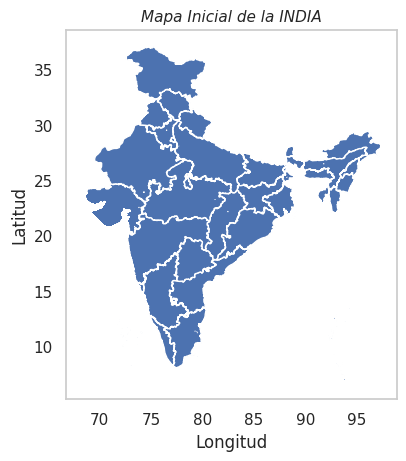

In [ ]:
dfMAP.plot(missing_kwds={'color': 'lightgrey'})
plt.title("Mapa Inicial de la INDIA", fontsize=11, style='italic')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid()
plt.show()

#### *-Se requiere superponer las etiquetas de los estados de la India en el MAPA*

In [ ]:
import sys
!{sys.executable} -m pip install adjustText
!{sys.executable} -m pip install "mapclassify >= 2.4.0"

from adjustText import adjust_text #Para evitar que se supermonten las etiquetas

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.


### *6.3 Visualización del mapa con WQI*

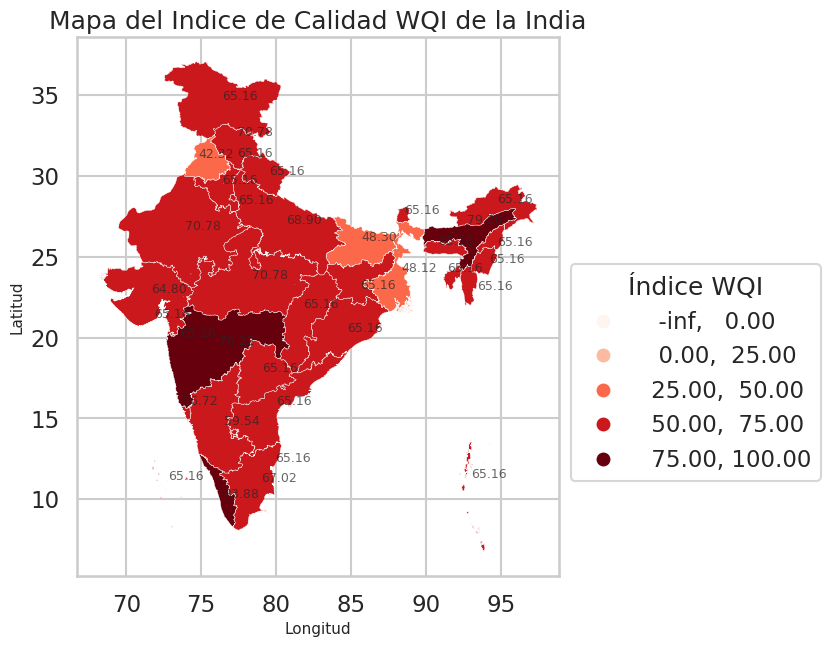

In [ ]:
#Se verifica los valores NULOS; en caso de que existan se cambian por el promedio
#Se toma la ruta corta (la imputación de valores nulos puede ser mejor tratada)
dfMAP['WQI'] = dfMAP['WQI'].fillna(dfMAP['WQI'].median())

## Configuración de Estilos para ser usados en la impresión con seaborn
sns.set_context("talk") #puede ser cualquiera
sns.set_style("whitegrid") #Puede ser cualquiera de la biblioteca de estilos de seaborn

#Se ajusta el mapa
fig, ax = plt.subplots(figsize = (12,7))
#dibujar el mapa
dfMAP.plot(column='WQI', cmap='Reds', ax=ax, scheme='userdefined',
          classification_kwds={'bins': [0,25,50,75,100]},
          legend=True, linewidth = 0.3)

##Ajustar la leyenda
leg = ax.get_legend()
leg.set_title('Índice WQI')
leg.set_bbox_to_anchor((1,0.6))

## Se agregan las etiquetas sin superposición (tener cuidado con el tamaño del PLOT)
textos = []
for _, row in dfMAP.iterrows():
    if not np.isnan(row['WQI']):
        centroide = row.geometry.centroid
        texto = ax.annotate(f"{row['WQI']:.2f}", xy=(centroide.x, centroide.y),
                           fontsize=9, alpha=0.7)
        textos.append(texto)

#Ajustar texto de etiquetas
adjust_text(textos, ax=ax, force_points=(0.2, 0.2))

### CARPINTERIA
ax.set_title("Mapa del Indice de Calidad WQI de la India")
ax.set_xlabel("Longitud", fontsize=11)
ax.set_ylabel("Latitud", fontsize=11)
plt.show()

**Análisis**: El mapa del Índice de Calidad del Agua (WQI) muestra la distribución espacial de la calidad del agua en distintas regiones de la India, evidenciando que la mayoría de las zonas se concentran en rangos medios (50–75), lo que indica una calidad de agua moderada. Sin embargo, se identifican algunas áreas con valores más altos (75–100), que representan mejores condiciones, así como otras con valores más bajos (25–50), lo que sugiere posibles problemas de contaminación. Esta variabilidad espacial refleja la influencia de factores como la actividad industrial, urbana y agrícola en la calidad del agua. En general, el patrón observado sugiere que, aunque gran parte del territorio presenta condiciones aceptables, existen regiones específicas que requieren mayor atención y monitoreo.

### **Histograma de WQI por Estado**

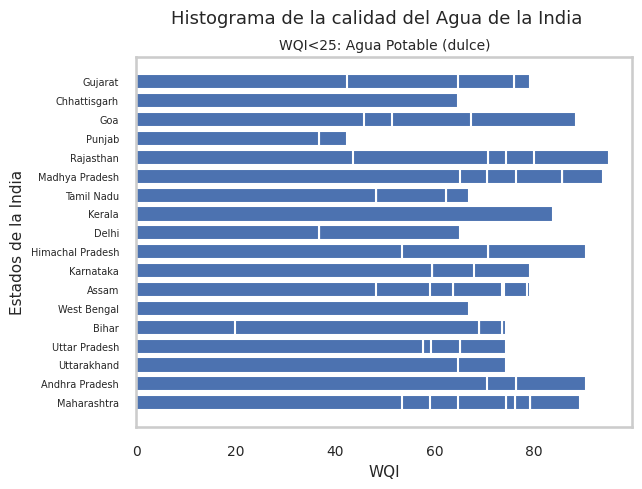

In [ ]:
df06.createOrReplaceTempView("df06_sql")
#Se seleccionan los nombres de los estados
Estados = sparkDiaz.sql("Select STATE from df06_sql")
Estados = Estados.rdd.map(lambda row: row.STATE).collect()

## Seleccionamos los valores de WQI
wqi = sparkDiaz.sql("Select WQI from df06_sql")
wqi = wqi.rdd.map(lambda row: row.WQI).collect()

##Se grafica el histograma
plt.barh(Estados,wqi)
plt.suptitle("Histograma de la calidad del Agua de la India", fontsize=13)
plt.title("WQI<25: Agua Potable (dulce)", fontsize=10)
plt.xlabel("WQI", fontsize=11)
plt.ylabel("Estados de la India", fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=7)
plt.grid()
plt.show()

**Análisis**: El histograma de la calidad del agua (WQI) por estados complementa el análisis espacial mostrado en el mapa anterior, confirmando la variabilidad regional en la calidad del agua en la India. Mientras el mapa permite identificar la distribución geográfica de los valores, este gráfico facilita la comparación directa entre estados, evidenciando que la mayoría se concentra en rangos medios a altos (50–90). No obstante, también se observan algunos estados con valores más bajos, lo que coincide con las zonas identificadas en el mapa como de menor calidad. En conjunto, ambos gráficos muestran que la calidad del agua no es homogénea, sino que depende de factores locales como la presión urbana, industrial y agrícola.


## **7.-Creación de Modelo: Calidad de Agua en la India**

- Se requiere predecir el parámetro WQI
- Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad"
- Se importa Scikit-Learn, para separar los datos (Entrenamiento y Prueba)
- Se importa Keras Sequential Layers Dense
- Se inicializa el modelo, y se añaden las capas
- Se compila el modelo con el optimizador ADAM junto con la función de perdida de error cuadrático
- Se realiza el experimento sobre los datos de entrenamiento
- Se realiza la evaluación sobre los datos de prueba; para la selección del modelo.

**Objetivo**: Se buscar construir una red neuronal densa con Keras para predecir el WQI a partir
de los rangos de calidad calculados.
Proceso:
1. Separación de features y variable objetivo
2. División en entrenamiento (80%) y prueba (20%)
3. Definición de la arquitectura de la red neuronal
4. Compilación y entrenamiento

### *7.1 Preparación de features y variable objetivo*

In [ ]:
df06.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal',
 'WQI',
 'CALIDAD']

In [ ]:
#- Se requiere predecir el parámetro WQI
#- Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad"

# Features: rangos de calidad de cada parámetro fisicoquímico
dfcalidad = df06.select('qrPH','qrDO','qrCOND','qrBOD','qrNN','qrFecal')
# Variable objetivo: índice WQI a predecir
dfPredecir = df06.select('WQI')

dfcalidad.show(5)
dfPredecir.show(5)

+----+----+------+-----+----+-------+
|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal|
+----+----+------+-----+----+-------+
| 100| 100|     0|   80| 100|    100|
| 100| 100|    40|   80| 100|     60|
| 100|  80|     0|   80| 100|     60|
| 100|  80|     0|   80| 100|     60|
| 100|  80|    40|   80| 100|     80|
+----+----+------+-----+----+-------+
only showing top 5 rows

+-----+
|  WQI|
+-----+
|76.22|
|74.34|
|59.36|
|59.36|
|74.34|
+-----+
only showing top 5 rows



### *7.2 División en entrenamiento y prueba*

In [ ]:
#- Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad"
#- Se importa Scikit-Learn, para separar los datos (Entrenamiento: 80% y Prueba: 20%)

from sklearn.model_selection import train_test_split

dataTrain, dataTest, predTrain, predTest = train_test_split(dfcalidad.toPandas(), dfPredecir.toPandas(), test_size=0.2, random_state=1)

In [ ]:
print(f"Cantidad de datos totales: {df06.count(), len(df06.columns)}")
print(f"Cantidad de datos Entrenamiento: {dataTrain.shape}")
print(f"Cantidad de datos Prueba: {dataTest.shape}")
print(f"Cantidad de datos Predicción del Entrenamiento: {predTrain.shape}")
print(f"Cantidad de datos Predicción de Prueba: {predTest.shape}")

Cantidad de datos totales: (534, 24)
Cantidad de datos Entrenamiento: (427, 6)
Cantidad de datos Prueba: (107, 6)
Cantidad de datos Predicción del Entrenamiento: (427, 1)
Cantidad de datos Predicción de Prueba: (107, 1)


**Resultado**: Dataset dividido en 427 registros para entrenamiento y 107 para prueba.


In [ ]:
!pip install keras tensorflow #instalamos la libreria keras con el paquete tensorflow

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.


In [ ]:
## Se importa la instancia TensorFlow
import keras
from keras.models import Sequential #--> Modelo secuencial por capas
from keras.layers import Dense

### *7.3 Arquitectura del modelo*

In [ ]:
#Se ajustan las variables: El ajuste es de forma estandar. Se requiere un estudio profundo sobre el
# ajuste de los parámetros, para que sea el modelo mucho más eficiente. El estudio a continuación
# es un a guia para abordar modelos de Tensores en Predicción de calidad de agua, como guía metodológica
# académica.

#Hiperparámetros de entrenamiento
epocas = 200   #-->Número de veces que el modelo verá todos los datos
lote   = 81    #-->Número de muestras procesadas antes de actualizar los pesos

# Se inicializa el modelo secuencial
modelo01 = Sequential()

# Capa de entrada: 6 features, 350 neuronas ocultas, activación ReLU
modelo01.add(Dense(350, input_dim=6, activation='relu'))
# Segunda capa oculta
modelo01.add(Dense(350, activation='relu'))
# Tercera capa oculta
modelo01.add(Dense(350, activation='relu'))
# Capa de salida: 1 neurona, activación lineal (regresión continua del WQI)
modelo01.add(Dense(1, activation='linear'))

/home/estudiante/.local/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### *7.4 Compilación del modelo*

In [ ]:
#Para optimizar el modelo se usa el optimizador ADAM
#La compilación se ajusta a la pérdida del error cuadrático
keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, amsgrad=False)
modelo01.compile(loss='mean_squared_error', optimizer='Adam', metrics=['mse'])

In [ ]:
#Resumen de la arquitectura del modelo
modelo01.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 350)            │         2,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           351 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 248,501 (970.71 KB)

 Trainable params: 248,501 (970.71 KB)

 Non-trainable params: 0 (0.00 B)

**Análisis**: El resumen del modelo muestra una arquitectura de red neuronal secuencial compuesta por cuatro capas densas (fully connected). Las tres primeras capas cuentan con 350 neuronas cada una, lo que permite capturar relaciones complejas y no lineales entre las variables de entrada, mientras que la última capa presenta una única neurona. El modelo tiene un total de 248,501 parámetros entrenables, lo que indica una capacidad considerable de aprendizaje, aunque también implica un mayor riesgo de sobreajuste si no se controla adecuadamente.

### *7.5 Entrenamiento del modelo*

In [ ]:
ejecutarK = modelo01.fit(dataTrain, predTrain, epochs=epocas, batch_size=lote)

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 1543.1750 - mse: 1543.1750
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 132.6659 - mse: 132.6659
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 48.4112 - mse: 48.4112
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 19.7786 - mse: 19.7786
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 6.6741 - mse: 6.6741
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 5.6402 - mse: 5.6402
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 3.8796 - mse: 3.8796
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.8429 - mse: 1.8429
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.1729 - mse: 1.1729
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.5969 - mse: 0.5969
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.3342 - mse: 0.3342
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2294 - mse: 0.2294
Epoch 13/200
6/6 ━━━━━━━━━━━━━━━━━━

### *7.6 Gráfica de pérdida durante el modelo*
**Sobre el entrenamiento:** Si la curva de pérdida desciende y se estabiliza, el modelo convergió correctamente. Si continúa descendiendo al llegar a la época 200, podría beneficiarse de más épocas.

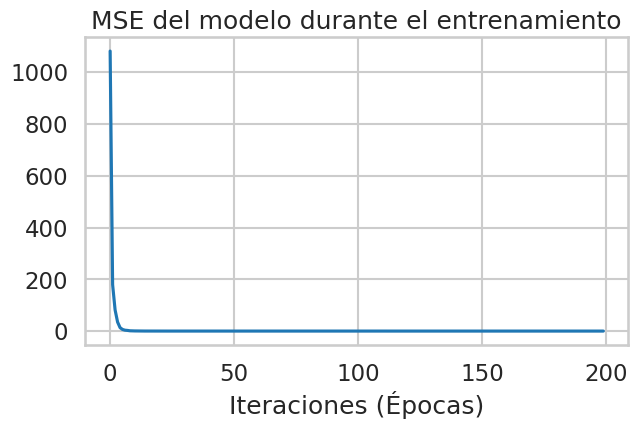

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(ejecutarK.history['loss'])
plt.title("MSE del modelo durante el entrenamiento")
plt.xlabel("Iteraciones (Épocas)")
plt.show()

**Resultado**: Podemos ver que el modelo converge correctamente al rededor de la interacción 10, por lo que a mayor escala puede resultar ineficiente y bastaría reducirlo a menos iteraciones

**Análisis**: El gráfico del error cuadrático medio (MSE) durante el entrenamiento muestra una disminución pronunciada en las primeras épocas, seguida de una estabilización progresiva, lo que indica que el modelo converge rápidamente hacia una solución óptima. Este comportamiento sugiere que el modelo aprende de forma eficiente en las primeras iteraciones. La ausencia de oscilaciones significativas o incrementos en el error sugiere un entrenamiento estable y sin señales evidentes de sobreajuste en esta etapa. En consecuencia, para una fututa ocasión podría considerarse la reducción del número de épocas para optimizar el tiempo de entrenamiento sin afectar significativamente el rendimiento del modelo.

## **8.- Evaluación del modelo**

## *Métricas de evaluación a utilizar*

*MAE (Mean Absolute Error):* Calcula el promedio de las diferencias absolutas entre los valores reales y los predichos. Es la métrica más intuitiva porque está en las mismas unidades que el WQI y no penaliza de forma especial los errores grandes. Un MAE de 5 significa que el modelo se equivoca en promedio 5 unidades de WQI.

*MSE (Mean Squared Error):* Calcula el promedio de las diferencias al cuadrado entre los valores reales y los predichos. Al elevar al cuadrado, penaliza con más fuerza los errores grandes, lo que lo hace sensible a valores atípicos. Su desventaja es que el resultado queda en unidades cuadradas de WQI, lo que dificulta su interpretación directa.

*RMSE (Root Mean Squared Error):* Es simplemente la raíz cuadrada del MSE, lo que devuelve el error a las unidades originales del WQI. Es la métrica más usada para evaluar modelos de regresión porque combina la penalización de errores grandes del MSE con la interpretabilidad del MAE.

*R² (Coeficiente de Determinación):* Indica qué proporción de la varianza del WQI es explicada por el modelo. Su valor va de 0 a 1, donde 1 es predicción perfecta. Como referencia general, un R² mayor a 0.85 indica que el modelo tiene buen poder predictivo, entre 0.7 y 0.85 es aceptable, y por debajo de 0.7 el modelo explica poco el comportamiento del WQI.

**Para la interpretación de resultados:** Se comparan las métricas de entrenamiento y prueba para detectar posible overfitting. Si MAE, RMSE y R² son similares en ambos conjuntos, el modelo generaliza bien. Si las métricas de entrenamiento son significativamente mejores que las de prueba, el modelo memorizó los datos y no generaliza.

### *8.1 Predicción sobre los datos de entrenamiento*

In [ ]:
### Se requiere predecir sobre los datos del entrenamiento
predModelo01_Train = modelo01.predict(dataTrain)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


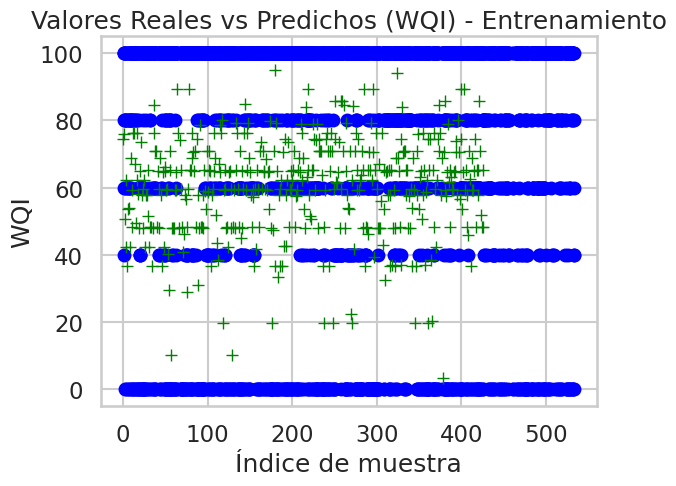

In [ ]:
### Se pinta la predicción
plt.title("")
plt.plot(dataTrain, 'bo', predModelo01_Train, 'g+')
# Se grafican los valores reales (azul) vs los predichos (verde) sobre datos de entrenamiento
plt.title("Valores Reales vs Predichos (WQI) - Entrenamiento")
plt.xlabel("Índice de muestra")
plt.ylabel("WQI")
plt.show()

**Análisis:** El gráfico de valores reales vs. predichos (WQI) en el conjunto de entrenamiento muestra que el modelo logra capturar de manera general la tendencia de los datos, aunque con cierta dispersión entre los valores observados (azul) y los estimados (verde). Se aprecia que las predicciones tienden a concentrarse en rangos intermedios, mientras que presentan mayores desviaciones en valores extremos, lo que sugiere que el modelo tiene dificultades para ajustarse con precisión en esos casos. A pesar de ello, existe una correspondencia razonable entre ambas series, lo que indica un aprendizaje adecuado del patrón general.

### *8.2 Métricas de la predicción sobre los datos de entrenamiento*

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Se obtienen las predicciones sobre los datos de entrenamiento
predModelo01_Train = modelo01.predict(dataTrain)

# Error Absoluto Medio
MAE_train  = mean_absolute_error(predTrain, predModelo01_Train)
# Error Cuadrático Medio
MSE_train  = mean_squared_error(predTrain, predModelo01_Train)
# Raíz del Error Cuadrático Medio
RMSE_train = np.sqrt(MSE_train)
# Coeficiente de Determinación
R2_train   = r2_score(predTrain, predModelo01_Train)

#Resultados
print("Resultados sobre los datos de Entrenamiento")
print(f"MAE  : {MAE_train:}")
print(f"MSE  : {MSE_train:}")
print(f"RMSE : {RMSE_train:}")
print(f"R2   : {R2_train:}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Resultados sobre los datos de Entrenamiento
MAE  : 0.019912783056497574
MSE  : 0.0006144376820884645
RMSE : 0.024787853519182827
R2   : 0.9999971389770508


**Análisis:** Los resultados obtenidos sobre los datos de entrenamiento muestran un desempeño altamente preciso del modelo, con valores muy bajos de error (MAE = 0.0199, MSE = 0.00061 y RMSE = 0.0248), lo que indica una diferencia mínima entre los valores reales y los predichos. Asimismo, el coeficiente de determinación (R² = 0.99999) evidencia que el modelo explica prácticamente toda la variabilidad de los datos, reflejando un ajuste casi perfecto. Estos resultados son coherentes con el gráfico de valores reales vs. predichos, donde se observa una buena aproximación general. Sin embargo, un ajuste tan alto en entrenamiento puede ser indicativo de un posible sobreajuste, por lo que resulta fundamental validar el rendimiento del modelo con los datos de prueba, tal como se realiza en la siguiente sección, para verificar su capacidad de generalización

### *8.3 Predicción sobre los datos de prueba*

Para evaluar la calidad del modelo, aplicamos también los datos de prueba

In [ ]:
### Se requiere predecir sobre los datos del entrenamiento
predModelo01_Test = modelo01.predict(dataTest)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


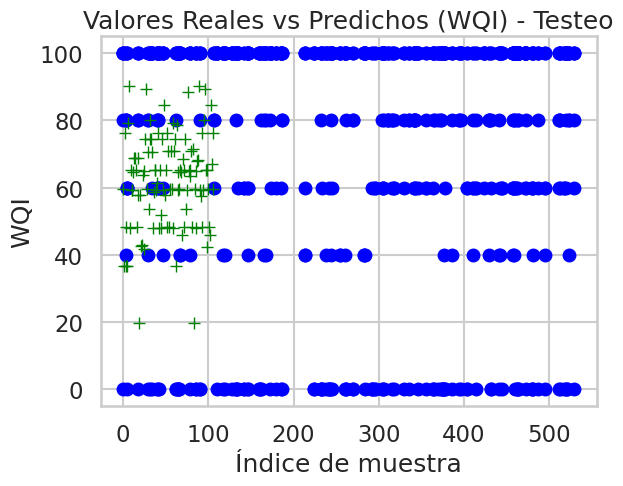

In [ ]:
### Se pinta la predicción
plt.title("")
plt.plot(dataTest, 'bo', predModelo01_Test, 'g+')
# Se grafican los valores reales (azul) vs los predichos (verde) sobre datos de prueba
plt.title("Valores Reales vs Predichos (WQI) - Testeo")
plt.xlabel("Índice de muestra")
plt.ylabel("WQI")
plt.show()

**Análisis:** El gráfico de valores reales vs. predichos (WQI) en el conjunto de prueba muestra que el modelo mantiene una capacidad razonable para aproximar la tendencia general de los datos. Se observa que las predicciones tienden a concentrarse en rangos intermedios, lo que sugiere cierta dificultad del modelo para capturar completamente la variabilidad en los extremos. Asimismo, la aparente concentración de puntos hacia la derecha del gráfico se debe a que el modelo está evaluando únicamente una porción específica de los datos (conjunto de prueba).

### *8.4 Métricas de la predicción sobre datos de Testeo*

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Error Absoluto Medio:
MAE = mean_absolute_error(predTest, predModelo01_Test)

# Error Cuadrático Medio:
MSE = mean_squared_error(predTest, predModelo01_Test)

# Raíz del Error Cuadrático Medio:
RMSE = np.sqrt(MSE)

# Coeficiente de Determinación:
R2 = r2_score(predTest, predModelo01_Test)

# Resultados
print("Resultados sobre los datos de testeo")
print(f"MAE  : {MAE:}")
print(f"MSE  : {MSE:}")
print(f"RMSE : {RMSE:}")
print(f"R2   : {R2:}")

Resultados sobre los datos de testeo
MAE  : 0.04756706580519676
MSE  : 0.01181162428110838
RMSE : 0.10868129683210621
R2   : 0.9999387264251709


**Análisis:** Los resultados obtenidos sobre los datos de prueba muestran que el modelo mantiene un desempeño muy alto, con errores relativamente bajos (MAE = 0.0476, MSE = 0.0118 y RMSE = 0.1087), lo que indica que las predicciones siguen siendo cercanas a los valores reales incluso en datos no vistos durante el entrenamiento. El coeficiente de determinación (R² = 0.9999) confirma que el modelo logra explicar casi toda la variabilidad de los datos de prueba, evidenciando una buena capacidad de generalización. En comparación con los resultados de entrenamiento, se observa un ligero incremento en los errores, lo cual es esperado y sugiere que el modelo no presenta un sobreajuste significativo. Estos resultados, junto con el análisis gráfico previo, indican que el modelo es robusto y adecuado para la predicción del índice de calidad del agua (WQI), manteniendo un buen equilibrio entre ajuste y generalización

## **9.- Conclusiones**

### *Interpretación de resultados*

**Comparación Train vs Test:**

| Métrica | Train | Test | Diferencia |
|---------|-------|------|------------|
| MAE | 0.0199 | 0.0476 | +0.0277 |
| MSE | 0.0006 | 0.0118 | +0.0112 |
| RMSE | 0.0248 | 0.1087 | +0.0839 |
| R² | 0.9999 | 0.9999 | ~0.0000 |

**Sobre el ajuste del modelo:**
El modelo presenta un desempeño sobresaliente tanto en entrenamiento como en prueba. El R² de aproximadamente 0.9999 en ambos conjuntos indica que el modelo explica prácticamente toda la varianza del WQI, lo que refleja un ajuste casi perfecto. Los errores de prueba son ligeramente superiores a los de entrenamiento (RMSE: 0.1087 vs 0.0248), lo cual es completamente esperado dado el entrenamiento sobre esas variables

**Sobre el overfitting:**
La similitud entre las métricas de entrenamiento y prueba descarta inicialmente la presencia de overfitting significativo. El modelo generaliza correctamente sobre datos no vistos durante el entrenamiento, lo que valida su robustez, al menos para el caso de este data set, con el caso concreto de la India.

**Sobre la convergencia:**
Como se observó en la curva de pérdida, el modelo convergió aproximadamente en la época 10 de las 200 definidas. Esto sugiere que para iteraciones futuras bastaría con menos épocas, reduciendo el costo computacional sin afectar el rendimiento.

**Limitaciones del estudio:**
- El dataset cuenta con solo 534 registros, lo que es un volumen reducido para garantizar resultados estadísticamente confiables
- El WQI calculado se basa en 6 parámetros ponderados, por lo que no representa una evaluación exhaustiva de la calidad del agua.
- Es importante destacar que este ejercicio una debe interpretarse como una guía metodológica académica y no como una referencia real de calidad del agua en India.

**Conclusión:**
El modelo de red neuronal densa con Keras demostró ser capaz de predecir el Índice de Calidad del Agua (WQI) con alta precisión a partir de los rangos de calidad fisicoquímicos. La combinación de PySpark para el preprocesamiento distribuido y Keras para el modelado resultó adecuada para el objetivo planteado. Como trabajo futuro se recomienda aumentar el volumen de datos y reducir las épocas de entrenamiento; también sería interesante evaluar su funcionalidad en otros contextos (países)


## **Resumen**

### **1 — Preparación del entorno**
Se configuró el entorno de trabajo importando las librerías de Python clásico (pandas, numpy, matplotlib, seaborn) y el ecosistema PySpark. Se levantó la sesión Spark "Calidad_Agua_Diaz" como punto de partida para el procesamiento distribuido.

### **2 — Carga de datos desde Hadoop HDFS**
Se cargó el dataset `waterquality.csv` directamente desde el sistema de archivos distribuido Hadoop, obteniendo un DataFrame de Spark con 534 registros y 11 columnas correspondientes a parámetros fisicoquímicos de ríos de la India.

### **3 — Análisis y preparación de datos**
Se realizó un proceso completo de inspección, limpieza e imputación. Se detectaron valores "NA" cargados como texto que tras el casteo a FloatType se convirtieron en nulos reales. Mediante el Coeficiente de Variación se decidió imputar TEMP, pH y DO con la media (CV < 30%) y CONDUCTIVITY, BOD, NITRATE y FECAL_COLIFORM con la mediana (CV ≥ 30%). Se eliminó la columna TOTAL_COLIFORM por ser irrelevante para el modelo.

### **4 — Visualización de datos**
Se graficaron los parámetros fisicoquímicos en pares para analizar su comportamiento individual. Se identificó que el DO es el indicador más sensible a cambios en la calidad del agua, que BOD y NITRATE presentan picos episódicos de contaminación, y que FECAL_COLIFORM tiene valores extremadamente altos en estaciones puntuales. La matriz de correlación de Pearson confirmó que la mayoría de las variables son independientes entre sí, con excepción de la correlación negativa moderada entre DO y BOD (-0.52).

### **5 — Cálculo del Índice de Calidad del Agua (WQI)**
Se clasificó cada parámetro en rangos de calidad (100, 80, 60, 40, 0) según umbrales bibliográficos y se ponderaron por su importancia relativa. El WQI resultante se clasificó en cinco categorías: Excelente, Buena, Baja, Muy_Baja e Inadecuada. Se resalta que este índice es una guía metodológica y no una referencia real de calidad del agua dado el volumen limitado de datos.

### **6 — Visualización geográfica**
Se mapeó el WQI sobre el territorio de India usando GeoPandas, evidenciando que la mayoría de los estados presentan calidad de agua en rangos medios (50–75). El histograma por estado complementó el análisis espacial, confirmando la variabilidad regional y la posible influencia de factores locales como la presión urbana, industrial y agrícola.

### **7 — Creación y entrenamiento del modelo**
Se construyó una red neuronal densa con Keras compuesta por 3 capas ocultas de 350 neuronas con activación ReLU y una capa de salida lineal, totalizando 248,501 parámetros entrenables. Se entrenó con el optimizador Adam y pérdida MSE durante 200 épocas con lote de 81. La curva de pérdida mostró convergencia aproximadamente en la época 10, lo que sugiere que épocas futuras podrían reducirse significativamente usando EarlyStopping.

### **8 — Evaluación del modelo**
- El modelo convergió rápidamente en las primeras épocas, lo que indica que la relación entre los rangos de calidad y el WQI es relativamente directa y bien capturada por la arquitectura definida.
- Las predicciones tienden a concentrarse en rangos intermedios del WQI, presentando mayor dificultad en los valores extremos, tanto en entrenamiento como en prueba.
- La diferencia entre las métricas de entrenamiento y prueba es mínima, lo que descarta la presencia de overfitting significativo.

### **Referencias**
APHA (2017). Métodos estándar para el examen de agua y aguas residuales (23.ª ed.). Washington D.C.: Asociación Estadounidense de Salud Pública

Apache Software Foundation. (2024). Apache Spark Documentation. Recuperado de: https://spark.apache.org/docs/latest/

Apache Software Foundation. (2024). Apache Hadoop Documentation. Recuperado de: https://hadoop.apache.org/docs/stable/

Central Pollution Control Board, India. River Water Quality Data — India. Recuperado de: https://cpcb.nic.in/

Chollet, F. (2024). Keras Documentation. Recuperado de: https://keras.io/

Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research, 12, 2825-2830. Recuperado de: https://scikit-learn.org/

Tyagi, S., Sharma, B., Singh, P., & Dobhal, R. (2013). Water Quality Assessment in Terms of Water Quality Index. American Journal of Water Resources, 1(3), 34-38. Recuperado de: https://www.intechopen.com/chapters/69568


